<a href="https://colab.research.google.com/github/emrizky1/machine-learning/blob/main/JS05/JS05_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv('spam.csv', encoding='cp1252')[["v1", "v2"]]
df.columns = ["label", "text"]

X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("\nClass distribution:")
print(y.value_counts())

Training data: (4457,)
Testing data: (1115,)

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


In [2]:
count_model = Pipeline([
    ("vectorizer", CountVectorizer(stop_words="english")),
    ("nb", MultinomialNB())
])

count_model.fit(X_train, y_train)
y_pred_count = count_model.predict(X_test)
accuracy_count = accuracy_score(y_test, y_pred_count)

print("Accuracy:", accuracy_count)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_count))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_count))

Accuracy: 0.9838565022421525

Confusion Matrix:
[[960   6]
 [ 12 137]]

Classification Report:
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.96      0.92      0.94       149

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



---
## 2

In [3]:
tfidf_model = Pipeline([
    ("vectorizer", TfidfVectorizer(stop_words="english")),
    ("nb", MultinomialNB())
])

tfidf_model.fit(X_train, y_train)
y_pred_tfidf = tfidf_model.predict(X_test)
accuracy_tfidf = accuracy_score(y_test, y_pred_tfidf)

print("Accuracy:", accuracy_tfidf)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tfidf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tfidf))

Accuracy: 0.968609865470852

Confusion Matrix:
[[966   0]
 [ 35 114]]

Classification Report:
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



---
## 3

In [4]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import precision_recall_fscore_support

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
for name, mdl, pred in [("CountVectorizer", count_model, y_pred_count),
                        ("TF-IDF", tfidf_model, y_pred_tfidf)]:
    p, r, f, _ = precision_recall_fscore_support(y_test, pred, pos_label="spam", average="binary")
    cv_scores = cross_val_score(mdl, X_train, y_train, cv=cv, scoring="accuracy")
    results.append({
        "Feature": name,
        "CV Accuracy": cv_scores.mean(),
        "Test Accuracy": accuracy_score(y_test, pred),
        "Spam Precision": p,
        "Spam Recall": r,
        "Spam F1": f,
    })

results_df = pd.DataFrame(results).set_index("Feature")
print(results_df.round(4))

                 CV Accuracy  Test Accuracy  Spam Precision  Spam Recall  \
Feature                                                                    
CountVectorizer       0.9868         0.9839           0.958       0.9195   
TF-IDF                0.9690         0.9686           1.000       0.7651   

                 Spam F1  
Feature                   
CountVectorizer   0.9384  
TF-IDF            0.8669  


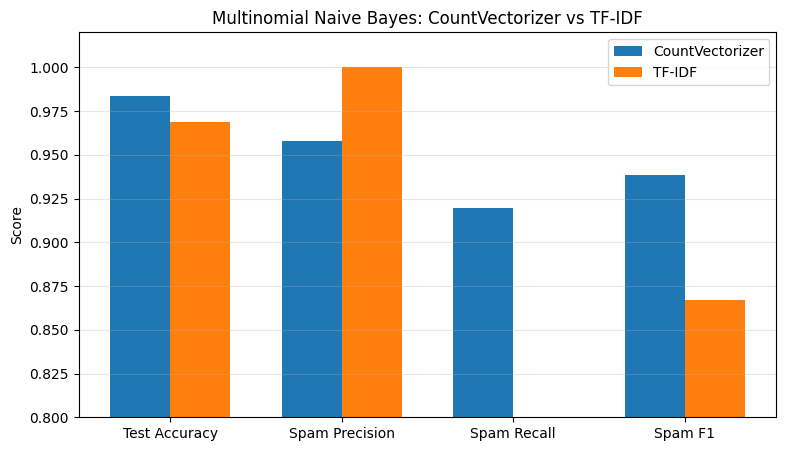

In [5]:
metrics = ["Test Accuracy", "Spam Precision", "Spam Recall", "Spam F1"]
x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, results_df.loc["CountVectorizer", metrics], width, label="CountVectorizer")
plt.bar(x + width/2, results_df.loc["TF-IDF", metrics], width, label="TF-IDF")

plt.xticks(x, metrics)
plt.ylim(0.8, 1.02)
plt.ylabel("Score")
plt.title("Multinomial Naive Bayes: CountVectorizer vs TF-IDF")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

---
## Analysis

1. Evaluate the results of Multinomial Naive Bayes with CountVectorizer (stop_words enabled).
  - Test accuracy 98.39% (5-fold CV accuracy 98.68%). Only 18 of 1115 test messages were misclassified: 6 ham flagged as spam and 12 spam missed.
  - Spam precision 0.96, recall 0.92, F1 0.94.

2. Evaluate the results of Multinomial Naive Bayes with TF-IDF (stop_words enabled) and compare with CountVectorizer.
  - Test accuracy 96.86% (5-fold CV accuracy 96.90%), about 1.5 points lower than CountVectorizer.
  - TF-IDF has perfect spam precision (1.00, zero ham flagged as spam), but spam recall drops to 0.77 (35 spam messages missed), so spam F1 falls to 0.87 versus 0.94.
  - A likely reason is that TfidfVectorizer L2-normalizes each message, so the feature values are small fractions instead of raw counts. For Multinomial Naive Bayes this makes the word evidence weaker relative to the class prior (about 87% ham), so borderline spam gets labeled ham. As a check, turning normalization off (norm=None) raised TF-IDF spam recall from 0.77 to 0.95.

3. Conclusion: which feature is optimal for spam.csv?
  - CountVectorizer is the better feature for this dataset. It leads on accuracy (both CV and test), spam recall and spam F1, and its CV and test scores agree, so the result is stable.
  - TF-IDF is only preferable if false positives (real messages blocked as spam) are much more costly than missed spam, since it never flagged a ham message.
